# Figure 07: Bound Bias Correction

Loads the calibration table produced by `Make_biasCorrection.ipynb` and plots
the bias correction example at DT = 2, lowest SNR — where the bias is largest
and the nonlinearity of the correction is most visible.

- **Gray**: raw measured (inferred) bound vs. true generative bound — reveals
  the systematic over-estimation at small bounds (overshoot regime).
- **Black**: corrected bound vs. true — should lie close to the identity.
- **Dotted**: identity line (perfect recovery).

Saves to `Figure07.pdf`.

## Setup

Loads the calibration table from `boundBiasCorrection.mat` (generated by
`Make_biasCorrection.ipynb`). Requires `boundSummary` (mean measured bound per
true-bound/DT/SNR cell) and `simBounds` (true bound grid) for the interpolation
correction, plus `boundBiasCorrection` (legacy linear coefficients) for display.

No data filtering — all calibration values are loaded as-is.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import scipy.io
import matplotlib.pyplot as plt

from pigeon.pathDefaults import BIAS_CORRECTION_FILE, FIGURES_DIR

WALL = 0.75   # screen-edge limit (matches simulation and real-data analysis)

mat = scipy.io.loadmat(BIAS_CORRECTION_FILE)
bound_summary   = mat['boundSummary']           # (n_bounds, MAX_RT, n_snrs)
sim_bounds      = mat['simBounds'].ravel()      # (n_bounds,)
bias_correction = mat['boundBiasCorrection']    # (MAX_RT, 2, n_snrs)
snrs            = mat['snrs'].ravel()           # (n_snrs,)

print(f'Loaded: {BIAS_CORRECTION_FILE}')
print(f'  bound_summary:   {bound_summary.shape}  (n_bounds × DT_bins × SNR_bins)')
print(f'  sim_bounds:      {sim_bounds.shape},  range [{sim_bounds.min():.2f}, {sim_bounds.max():.2f}]')
print(f'  SNR bins:        {np.round(snrs, 3)}')

Loaded: /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Data/Processed/Python/boundBiasCorrection.mat
  bound_summary:   (19, 12, 3)  (n_bounds × DT_bins × SNR_bins)
  sim_bounds:      (19,),  range [0.01, 0.70]
  SNR bins:        [0.333 0.667 1.   ]


## Summary figure

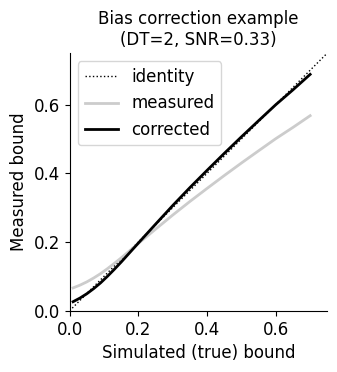

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure07_formatted.pdf


In [ ]:
CM = 1 / 2.54
WID = 8.5   # cm (1 JNeurosci column)
FS  = 12

rt_idx = 1   # DT = 2 (0-indexed)
mm     = 0   # lowest SNR

x_true = sim_bounds
x_meas = bound_summary[:, rt_idx, mm]
valid  = np.isfinite(x_meas)

coeffs = bias_correction[rt_idx, :, mm]   # [intercept, slope]: true = a + b*measured
x_corr = np.maximum(0.005, coeffs[0] + coeffs[1] * np.abs(x_meas[valid]))

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

fig, ax = plt.subplots(figsize=(WID * CM, WID * CM))
ax.plot([0, WALL], [0, WALL], 'k:',  linewidth=1,   label='identity')
ax.plot(x_true[valid], x_meas[valid], '-', color='0.8', linewidth=2, label='measured')
ax.plot(x_true[valid], x_corr,        'k-', linewidth=2,              label='corrected')

ax.set_xlim(0, WALL)
ax.set_ylim(0, WALL)
ax.set_aspect('equal')
ax.set_xlabel('Simulated (true) bound')
ax.set_ylabel('Measured bound')
ax.set_title(f'Bias correction example\n(DT={rt_idx+1}, SNR={snrs[mm]:.2f})')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure07.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')